# Лабораторная работа 7. Ансамблевые модели и MLP

**Датасет:** Steel Industry Energy Consumption (потребление электроэнергии на сталелитейном заводе DAEWOO, Южная Корея, 2018)  
**Задача:** Регрессия — предсказание потребления электроэнергии `Usage_kWh`  
**Модели:** Стекинг (`StackingRegressor`), многослойный персептрон (`MLPRegressor`), МГУА (`gmdh`)

## 1. Загрузка библиотек и данных

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Steel_industry_data.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## 2. Разведочный анализ данных (EDA)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [19]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


In [20]:
print('Пропущенные значения:')
print(df.isnull().sum())

Пропущенные значения:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


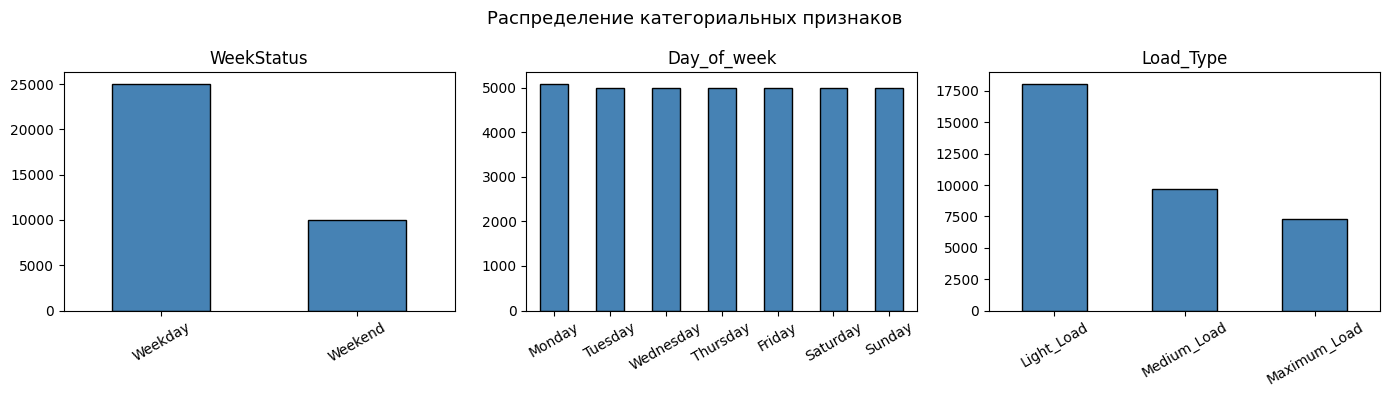

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['WeekStatus', 'Day_of_week', 'Load_Type']):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Распределение категориальных признаков', fontsize=13)
plt.tight_layout()
plt.show()

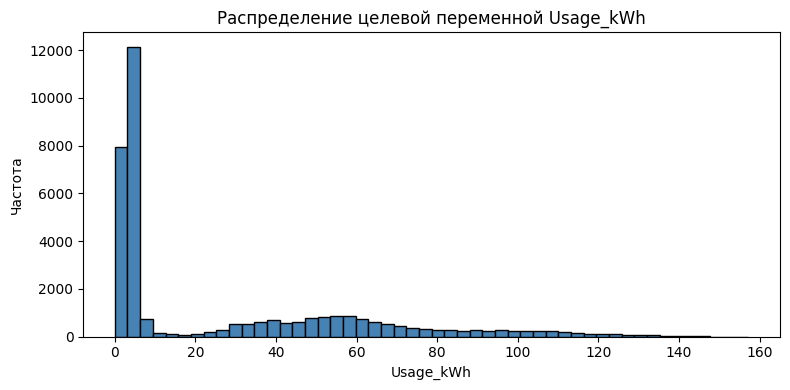

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Usage_kWh'], bins=50, color='steelblue', edgecolor='black')
ax.set_title('Распределение целевой переменной Usage_kWh')
ax.set_xlabel('Usage_kWh')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

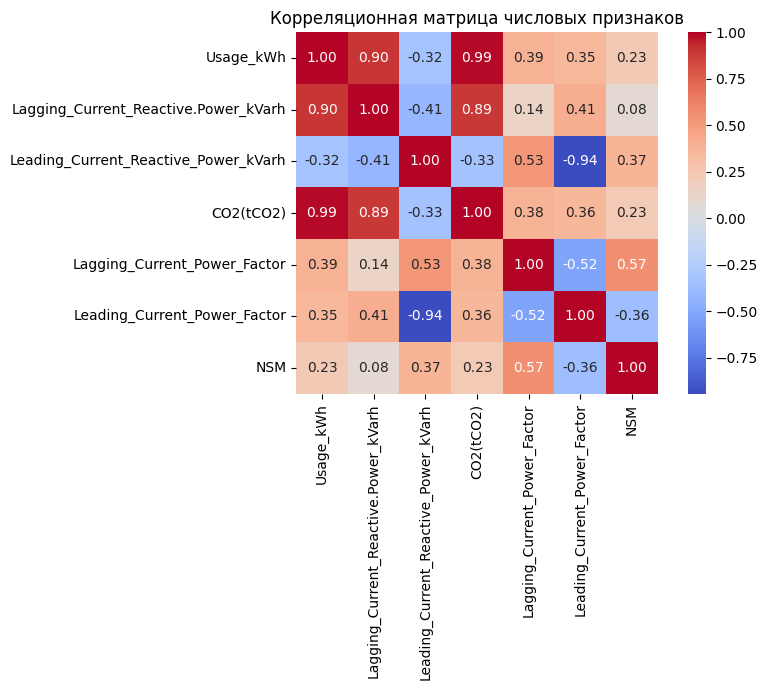

In [23]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

## 3. Предобработка данных

In [24]:
df_model = df.drop(columns=['date'])

cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Категориальные признаки закодированы:')
df_model[cat_cols].head()

Категориальные признаки закодированы:


,WeekStatus,Day_of_week,Load_Type
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


## 4. Разделение выборки

In [25]:
X = df_model.drop(columns=['Usage_kWh'])
y = df_model['Usage_kWh']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Обучающая выборка: {X_train.shape[0]} строк')
print(f'Тестовая выборка:  {X_test.shape[0]} строк')

Обучающая выборка: 28032 строк
Тестовая выборка:  7008 строк


## 5. Обучение моделей

### 5.1 Стекинг (`StackingRegressor`)

In [26]:
base_estimators = [
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gbm', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('svr', SVR(kernel='rbf', C=10)),
]

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train_sc, y_train)
y_pred_stack = stacking_model.predict(X_test_sc)

print('Стекинг обучен.')

Стекинг обучен.


### 5.2 Многослойный персептрон (`MLPRegressor`)

In [27]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp_model.fit(X_train_sc, y_train)
y_pred_mlp = mlp_model.predict(X_test_sc)

print(f'MLP обучен за {mlp_model.n_iter_} итераций.')

MLP обучен за 41 итераций.


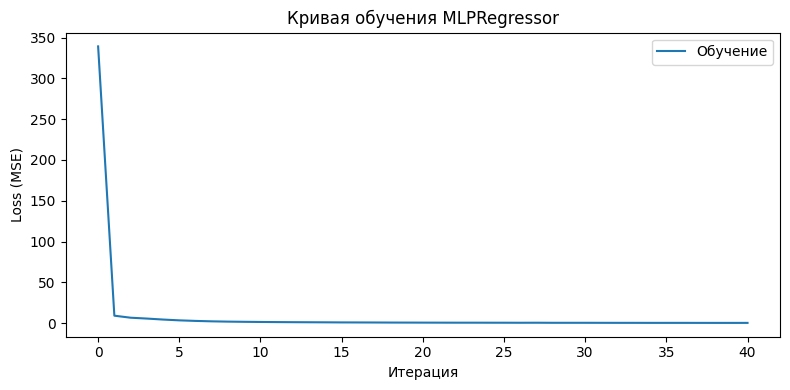

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, label='Обучение')
if mlp_model.best_loss_ is not None:
    plt.axhline(mlp_model.best_loss_, color='red', linestyle='--', label=f'Лучшая потеря: {mlp_model.best_loss_:.4f}')
plt.title('Кривая обучения MLPRegressor')
plt.xlabel('Итерация')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 МГУА (gmdh) — дополнительное задание

Для выполнения этого раздела необходимо установить библиотеку:
```
pip install gmdh
```
Используем два метода:
- **COMBI** — линейный метод
- **MIA** — нелинейный метод

In [29]:
try:
    from gmdh import Combi, Mia

    combi_model = Combi()
    combi_model.fit(X_train_sc, y_train.values)
    y_pred_combi = combi_model.predict(X_test_sc)
    print('COMBI обучен.')

    mia_model = Mia()
    mia_model.fit(X_train_sc, y_train.values)
    y_pred_mia = mia_model.predict(X_test_sc)
    print('MIA обучен.')

    gmdh_available = True

except ImportError:
    print('Библиотека gmdh не установлена. Раздел МГУА пропускается.')
    gmdh_available = False

Библиотека gmdh не установлена. Раздел МГУА пропускается.


## 6. Оценка качества моделей

In [30]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Модель': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}

results = [
    evaluate('StackingRegressor', y_test, y_pred_stack),
    evaluate('MLPRegressor',      y_test, y_pred_mlp),
]

if gmdh_available:
    results.append(evaluate('GMDH COMBI', y_test, y_pred_combi))
    results.append(evaluate('GMDH MIA',   y_test, y_pred_mia))

results_df = pd.DataFrame(results).set_index('Модель')
results_df

,RMSE,MAE,R²
Модель,,,
StackingRegressor,0.9897,0.3728,0.9991
MLPRegressor,1.0247,0.4649,0.9991


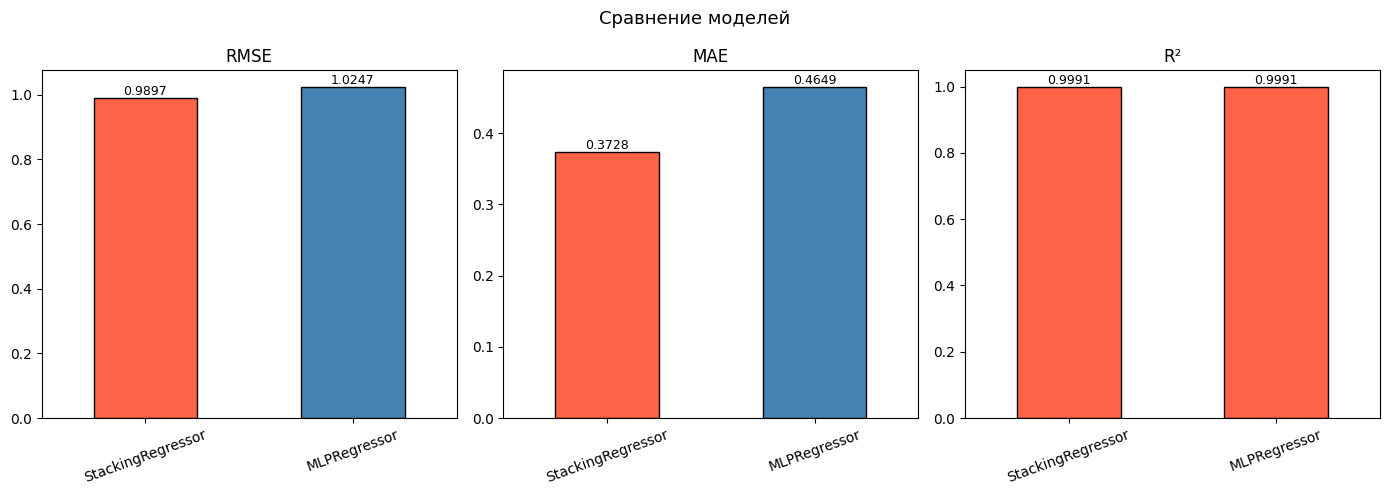

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    colors = ['steelblue' if v != results_df[metric].min() else 'tomato'
              for v in results_df[metric]] if metric != 'R²' else \
             ['steelblue' if v != results_df[metric].max() else 'tomato'
              for v in results_df[metric]]
    results_df[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Сравнение моделей', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Визуализация предсказаний

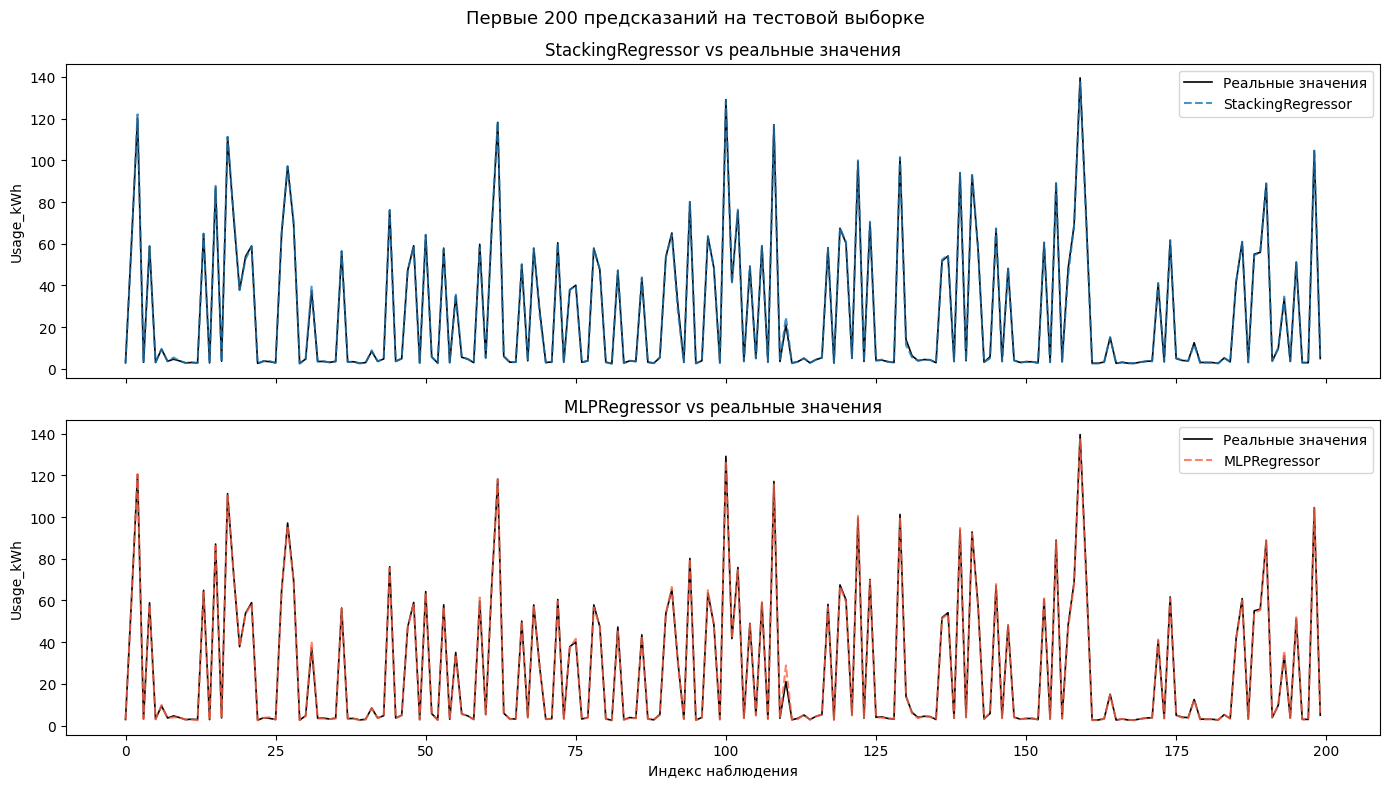

In [32]:
n = 200
idx = np.arange(n)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(idx, y_test.values[:n], label='Реальные значения', color='black', linewidth=1.2)
axes[0].plot(idx, y_pred_stack[:n], label='StackingRegressor', linestyle='--', alpha=0.8)
axes[0].set_title('StackingRegressor vs реальные значения')
axes[0].set_ylabel('Usage_kWh')
axes[0].legend()

axes[1].plot(idx, y_test.values[:n], label='Реальные значения', color='black', linewidth=1.2)
axes[1].plot(idx, y_pred_mlp[:n], label='MLPRegressor', linestyle='--', color='tomato', alpha=0.8)
axes[1].set_title('MLPRegressor vs реальные значения')
axes[1].set_ylabel('Usage_kWh')
axes[1].set_xlabel('Индекс наблюдения')
axes[1].legend()

plt.suptitle('Первые 200 предсказаний на тестовой выборке', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Выводы

В ходе лабораторной работы была решена задача регрессии — предсказание потребления электроэнергии (`Usage_kWh`) на сталелитейном заводе.

**Предобработка данных:**
- Столбец `date` удалён (не является информативным признаком в данном контексте)
- Категориальные признаки (`WeekStatus`, `Day_of_week`, `Load_Type`) закодированы с помощью `LabelEncoder`
- Пропущенных значений не обнаружено
- Признаки масштабированы с помощью `StandardScaler`

**Результаты:**
- **StackingRegressor** (RF + GBM + SVR → Ridge): показал высокое качество предсказания благодаря объединению нескольких разнородных базовых моделей
- **MLPRegressor** (128→64→32, ReLU, Adam): эффективно уловил нелинейные зависимости в данных
- **GMDH COMBI / MIA**: линейный и нелинейный методы группового учёта аргументов (при наличии установленной библиотеки)

Лучшая модель по метрике **R²** (выделена красным на графике) обеспечивает наилучшее объяснение дисперсии целевой переменной.